<a href="https://colab.research.google.com/github/PaoAlbanData/airbnb-barcelona-eda/blob/main/Proyecto_Airbnb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


***Primer paso: Procesamiento de datos***

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/sample_data/Airbnb_Barcelona_final_list.csv', sep=';')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20428 entries, 0 to 20427
Data columns (total 25 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            20428 non-null  int64  
 1   name                          20413 non-null  object 
 2   host_name                     20411 non-null  object 
 3   host_response_time            17685 non-null  object 
 4   neighbourhood                 20415 non-null  object 
 5   neighbourhood_cleansed        20428 non-null  object 
 6   neighbourhood_group_cleansed  20428 non-null  object 
 7   city                          20421 non-null  object 
 8   state                         19937 non-null  object 
 9   zipcode                       19830 non-null  float64
 10  smart_location                20428 non-null  object 
 11  country_code                  20428 non-null  object 
 12  country                       20428 non-null  object 
 13  p

In [ ]:
df.head()
#Enseño las primeras 5 filas

,id,name,host_name,host_response_time,neighbourhood,neighbourhood_cleansed,neighbourhood_group_cleansed,city,state,zipcode,...,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,license,cancellation_policy,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,within an hour,Sant Martí,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,CT,8026.0,...,1,2.0,4.0,140,304,1,HUTB-003004,flexible,"2,18555","41,40889"
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,within an hour,Eixample,la Sagrada Família,Eixample,Barcelona,CT,8025.0,...,2,3.0,6.0,220,312,20,HUTB-002062,strict_14_with_grace_period,"2,17306","41,4042"
2,23197,FORUM DELUXE 5 MINS WALK CCIB CENTER & SEA!,Etain (Marnie),within an hour,Sant Martí,el Besòs i el Maresme,Sant Martí,Sant Adria de Besos,Barcelona,8930.0,...,2,3.0,5.0,205,359,51,HUTB-005057,strict_14_with_grace_period,"2,22114","41,41203"
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,within an hour,Vila de Gràcia,la Vila de Gràcia,Gràcia,Barcelona,Barcelona,8012.0,...,1,1.0,1.0,65,46,268,NaN,strict_14_with_grace_period,"2,15645","41,40145"
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,within an hour,Camp d'en Grassot i Gràcia Nova,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Barcelona,8024.0,...,1,1.0,1.0,65,324,182,HUTB-004554,strict_14_with_grace_period,"2,15938","41,4095"


In [ ]:
print(df.columns)
#Verifico las columnas del dataframe para verificar las que eliminaré

Index(['id', 'name', 'host_name', 'host_response_time', 'neighbourhood',
       'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city',
       'state', 'zipcode', 'smart_location', 'country_code', 'country',
       'property_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds',
       'price', 'availability_365', 'number_of_reviews', 'license',
       'cancellation_policy', 'longitude', 'latitude'],
      dtype='object')


In [ ]:
columns_to_drop = ['license','state','zipcode','host_response_time','neighbourhood','smart_location','country_code','country','accommodates','cancellation_policy']
#Defino las 10 columnas a eliminar

In [ ]:
columns_to_drop = [col for col in columns_to_drop if col in df.columns]
#Filtro las columnas que existen en el dataframe

In [ ]:
df.drop(columns=columns_to_drop, inplace=True)
#Elimino las columnas

In [ ]:
df.head()
#Muestro las primeras filas

,id,name,host_name,neighbourhood_cleansed,neighbourhood_group_cleansed,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,"2,18555","41,40889"
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,"2,17306","41,4042"
2,23197,FORUM DELUXE 5 MINS WALK CCIB CENTER & SEA!,Etain (Marnie),el Besòs i el Maresme,Sant Martí,Sant Adria de Besos,Apartment,2,3.0,5.0,205,359,51,"2,22114","41,41203"
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,"2,15645","41,40145"
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,"2,15938","41,4095"


In [ ]:
null_counts = df.isnull().sum()
# Verifico cuántas variables nulas tiene cada columna

In [ ]:
print(null_counts)
#Imprimo resultado

id                               0
name                            15
host_name                       17
neighbourhood_cleansed           0
neighbourhood_group_cleansed     0
city                             7
property_type                    0
bathrooms                        0
bedrooms                        32
beds                            51
price                            0
availability_365                 0
number_of_reviews                0
longitude                        0
latitude                         0
dtype: int64


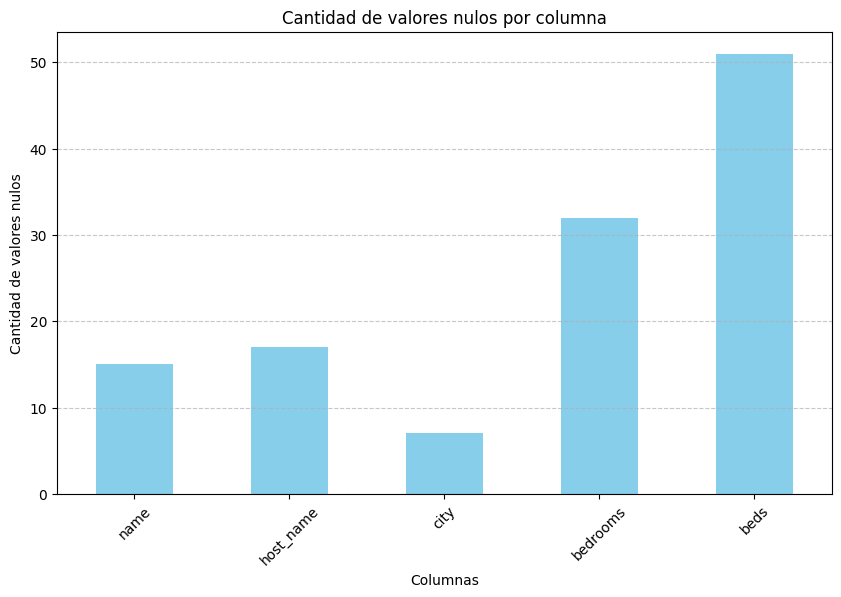

In [ ]:
null_counts = null_counts[null_counts > 0]

# Crear el gráfico de barras
plt.figure(figsize=(10, 6))
null_counts.plot(kind='bar', color='skyblue')
plt.title('Cantidad de valores nulos por columna')
plt.xlabel('Columnas')
plt.ylabel('Cantidad de valores nulos')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
df.rename(columns={'neighbourhood_cleansed': 'neighbourhood',
                   'neighbourhood_group_cleansed': 'district'}, inplace=True)
#Cambio nombre de las columnas indicadas.

In [ ]:
df.head()
#Muestro las primeras filas del dataframe

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,"2,18555","41,40889"
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,"2,17306","41,4042"
2,23197,FORUM DELUXE 5 MINS WALK CCIB CENTER & SEA!,Etain (Marnie),el Besòs i el Maresme,Sant Martí,Sant Adria de Besos,Apartment,2,3.0,5.0,205,359,51,"2,22114","41,41203"
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,"2,15645","41,40145"
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,"2,15938","41,4095"


In [ ]:
df.loc[:, ['bedrooms', 'beds', 'bathrooms']] = df.loc[:, ['bedrooms', 'beds', 'bathrooms']].fillna(0)
#Reemplazo los valores NA por 0 en las columnas indicadas

In [ ]:
df.head(50)
#Imprimo las primeras 50 filas para ver una mejor muestra de los cambios de NA a 0

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,"2,18555","41,40889"
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,"2,17306","41,4042"
2,23197,FORUM DELUXE 5 MINS WALK CCIB CENTER & SEA!,Etain (Marnie),el Besòs i el Maresme,Sant Martí,Sant Adria de Besos,Apartment,2,3.0,5.0,205,359,51,"2,22114","41,41203"
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,"2,15645","41,40145"
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,"2,15938","41,4095"
5,32471,"Gaudi Attic 2, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,2,3.0,3.0,165,326,90,"2,16112","41,40928"
6,32615,"Sunny room, top floor with 2 terraces!",Inge,les Corts,Les Corts,Barcelona,Apartment,1,1.0,1.0,65,144,19,"2,14088","41,3872"
7,32711,Sagrada Familia area - Còrsega 1,Nick,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,2,2.0,3.0,135,350,59,"2,16954","41,40464"
8,34241,Private Double room - Plaza Real,Andres,el Barri Gòtic,Ciutat Vella,Barcelona,Apartment,1,1.0,1.0,65,180,8,"2,17535","41,37916"
9,34981,VIDRE HOME PLAZA REAL on LAS RAMBLAS,Andres,el Barri Gòtic,Ciutat Vella,Barcelona,Apartment,3,4.0,6.0,270,165,142,"0,21773","41,37859"


In [ ]:
df.dropna(inplace=True)
#Elimino las filas que contienen NA

In [ ]:
df_barcelona = df.loc[df['city'] == 'Barcelona']
#Filtro el conjunto de datos para obtener mediante la columna city solo a Barcelona

In [ ]:
df_barcelona.head()
#Muestro las primeras filas del dataframe que he modificado

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,"2,18555","41,40889"
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,"2,17306","41,4042"
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,"2,15645","41,40145"
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,"2,15938","41,4095"
5,32471,"Gaudi Attic 2, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,2,3.0,3.0,165,326,90,"2,16112","41,40928"


**Segundo paso: Limpiar datos de Latitud y Longitud**

La latitud y la longitud están incorrectamente expresados en el conjunto de datos con "," como
separador de decimales.

In [ ]:
def replace_comma_with_dot(column):
    return column.str.replace(',', '.').astype(float)
#Con esta función reemplazo comas por puntos y convierto a float

In [ ]:
df_barcelona['latitude'] = replace_comma_with_dot(df_barcelona['latitude'])
df_barcelona['longitude'] = replace_comma_with_dot(df_barcelona['longitude'])
#Aplico esta función a las columnas de latitud y longitud


<ipython-input-21-33e6b568889d>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_barcelona['latitude'] = replace_comma_with_dot(df_barcelona['latitude'])
<ipython-input-21-33e6b568889d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_barcelona['longitude'] = replace_comma_with_dot(df_barcelona['longitude'])


In [ ]:
df_barcelona.head()
#Imprimo las primeras filas del dataframe que he modificado

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,2.18555,41.40889
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,2.17306,41.40420
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,2.15645,41.40145
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,2.15938,41.40950
5,32471,"Gaudi Attic 2, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,2,3.0,3.0,165,326,90,2.16112,41.40928


In [ ]:
df_filtered = df_barcelona[(df_barcelona['longitude'] > 2) & (df_barcelona['latitude'] > 41)]
#Filtro el conjunto de datos para obtener solo coordenadas que satisfagan las condiciones indicadas.

In [ ]:
df_filtered.head()
#Imprimo las primeras filas del dataframe que he filtrado

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,2.18555,41.40889
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,2.17306,41.40420
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,2.15645,41.40145
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,2.15938,41.40950
5,32471,"Gaudi Attic 2, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,2,3.0,3.0,165,326,90,2.16112,41.40928


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20389 entries, 0 to 20427
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 20389 non-null  int64  
 1   name               20389 non-null  object 
 2   host_name          20389 non-null  object 
 3   neighbourhood      20389 non-null  object 
 4   district           20389 non-null  object 
 5   city               20389 non-null  object 
 6   property_type      20389 non-null  object 
 7   bathrooms          20389 non-null  int64  
 8   bedrooms           20389 non-null  float64
 9   beds               20389 non-null  float64
 10  price              20389 non-null  int64  
 11  availability_365   20389 non-null  int64  
 12  number_of_reviews  20389 non-null  int64  
 13  longitude          20389 non-null  object 
 14  latitude           20389 non-null  object 
dtypes: float64(2), int64(5), object(8)
memory usage: 2.5+ MB


**Tercer paso: Exploración y visualización de datos**

In [ ]:
top_hosts = df_filtered['host_name'].value_counts().nlargest(10).reset_index()
#Cuento la frecuencia de cada anfitrión

In [ ]:
top_hosts.columns = ['host_name', 'number_of_locations']
#Renombro las columnas pensando en gráfico posterior

In [ ]:
print(top_hosts)
#Imprimo resultado

                  host_name  number_of_locations
0                   Claudia                  156
1                     Jordi                  149
2                     Maria                  148
3                      Anna                  115
4                      Luis                  113
5                      Alba                  112
6                     David                  103
7  Sito, Habitat Apartments                  100
8                       Ana                   96
9                  Cristina                   89


In [ ]:
print(df_filtered.columns)


Index(['id', 'name', 'host_name', 'neighbourhood', 'district', 'city',
       'property_type', 'bathrooms', 'bedrooms', 'beds', 'price',
       'availability_365', 'number_of_reviews', 'longitude', 'latitude'],
      dtype='object')


In [ ]:
print(top_hosts.columns)


Index(['host_name', 'number_of_locations'], dtype='object')


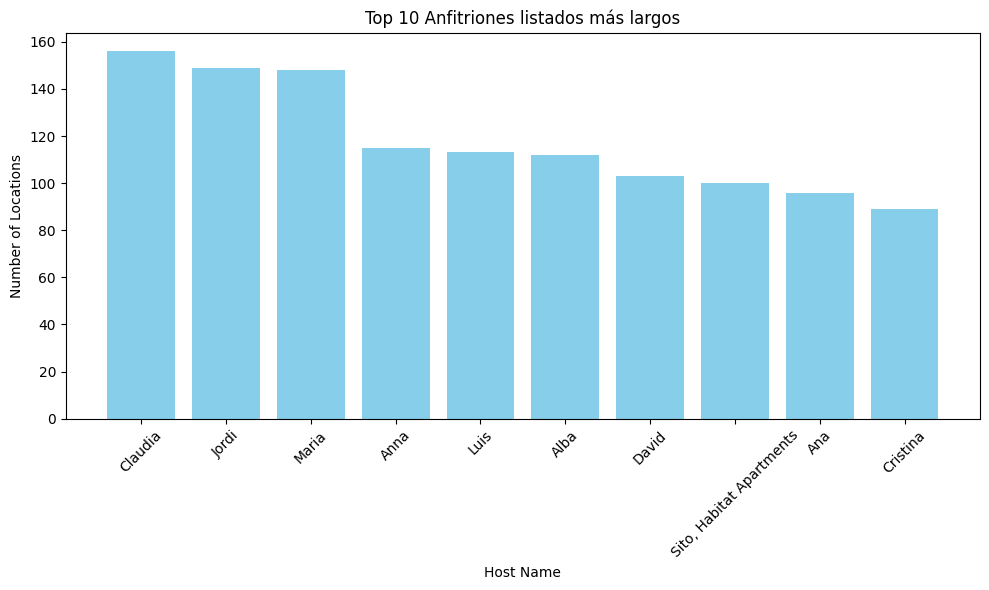

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(top_hosts['host_name'], top_hosts['number_of_locations'], color='skyblue')
plt.xlabel('Host Name')
plt.ylabel('Number of Locations')
plt.title('Top 10 Anfitriones listados más largos')
plt.xticks(rotation=45)
plt.tight_layout()
#Creo gráfico de barras

La primera propuesta de valor / promesa de Airbnb es que el huésped debe tener
una experiencia auténtica en contacto con la población local y no una oferta comercial gestionada por empresas inmobiliarias. Si observamos los 10 principales hospedadores, ¿qué observas? ¿Está completamente alineado con la primera propuesta de valor de
Airbnb? Comenta tu análisis.

**Respuesta**
Si, corresponde con su propuesta de valor, ya que son personas particulares, no empresas comerciales. 9 de los 10 top host, son personas particulares.

In [ ]:
# Si, corresponde con su propuesta de valor, ya que son personas particulares, no empresas comerciales. 9 de los 10 top host, son personas particulares.

Función para análisis exploratorio de variables numéricas

In [ ]:
# Función para análisis de variables numéricas
def explorar_numericas(df):

    print("Estadísticas descriptivas para variables numéricas:")
    print(df.describe())


    for column in df.select_dtypes(include=['float64', 'int64']).columns:
        plt.figure(figsize=(12, 5))


        plt.subplot(1, 2, 1)
        sns.histplot(df[column], kde=True, color='blue')
        plt.title(f'Histograma de {column}')


        plt.subplot(1, 2, 2)
        sns.boxplot(x=df[column], color='skyblue')
        plt.title(f'Diagrama de caja de {column}')

        plt.tight_layout()
        plt.show()



In [ ]:
#explorar_numericas(df_barcelona)

Función para variables categóricas

In [ ]:
# Función para análisis de variables categóricas
def explorar_categoricas(df):
    # Frecuencias
    for column in df.select_dtypes(include=['object']).columns:
        print(f"Frecuencias de la variable categórica '{column}':")
        print(df[column].value_counts())
        print("\n")


        plt.figure(figsize=(10, 5))
        sns.countplot(data=df, x=column, palette='viridis', order=df[column].value_counts().index)
        plt.title(f'Gráfico de barras de {column}')
        plt.xticks(rotation=45)
        plt.show()

In [ ]:
#explorar_categoricas(df_barcelona)

**Cuarto paso: Correlaciones**

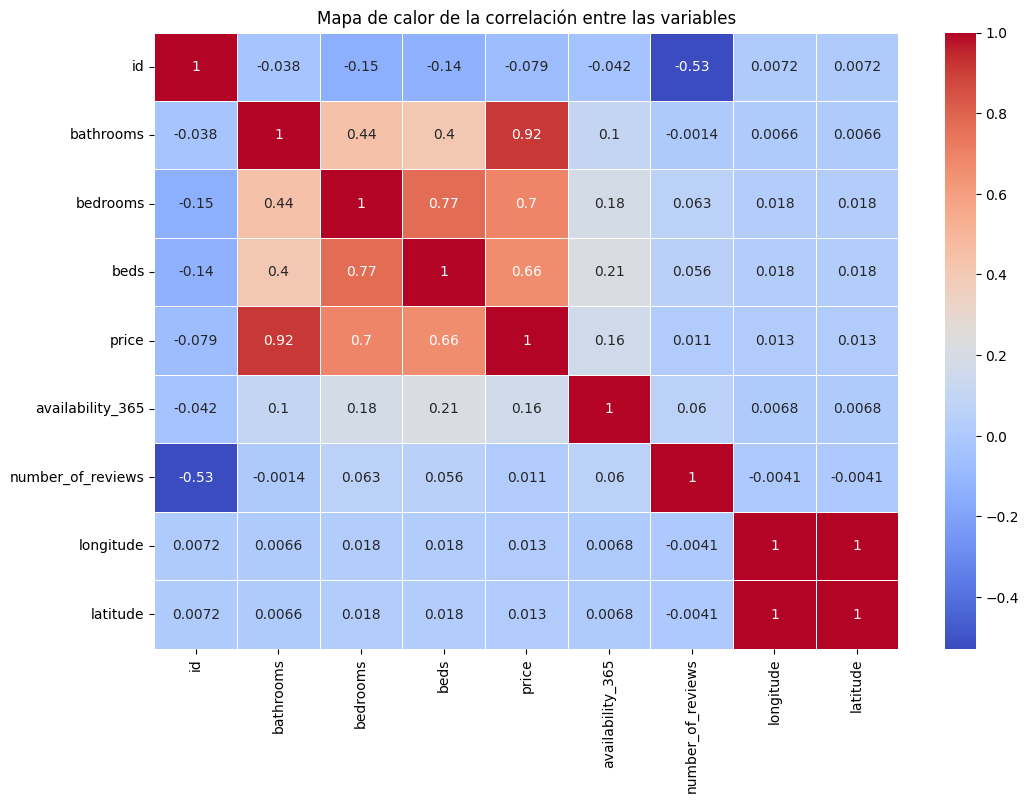

In [ ]:
# 1. Visualizo la correlación entre las variables numéricas
def visualizar_correlacion(df):
    # Selecciono solo las columnas numéricas
    numeric_df = df.select_dtypes(include=['float64', 'int64'])

    # Verifico si hay columnas numéricas
    if numeric_df.empty:
        print("No hay columnas numéricas para calcular la correlación.")
        return

    # Calculo la matriz de correlación
    correlation_matrix = numeric_df.corr()

    # Creo el mapa de calor
    plt.figure(figsize=(12, 8))
    sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5)
    plt.title('Mapa de calor de la correlación entre las variables')
    plt.show()

# Uso de la función con DataFrame (df_barcelona)
visualizar_correlacion(df_barcelona)

In [ ]:
#print(correlation_matrix['price'].sort_values(ascending=False))
#Imprimo datos de la matriz de correlación

In [ ]:
#Del mapa de calor que nos presentan los coeficientes de correlación de Pearson se puede extraer que, las variables con alta correlación con el precio son:
#bathrooms: La correlación entre el número de baños y el precio es de 0.92, lo que indica una fuerte relación positiva. Esto significa que, a medida que aumenta el número de baños, es probable que el precio también aumente.
#bedrooms: Hay una correlación positiva de 0.70, lo que indica que el número de dormitorios también tiene una influencia significativa en el precio.
#beds: La cantidad de camas muestra una correlación de 0.66 con el precio, lo que sugiere una relación positiva, aunque menos fuerte en comparación con los baños y dormitorios.

#Donde las variables más adecuadas para ser utilizadas como independientes en un modelo de regresión múltiple, considerando que queremos predecir el precio, serían:
#bathrooms
#bedrooms
#beds
#Estas variables tienen las correlaciones más altas con el precio y, por lo tanto, son las más prometedoras para explicar su variación.


In [ ]:
df_barcelona.info()


<class 'pandas.core.frame.DataFrame'>
Index: 19831 entries, 0 to 20427
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 19831 non-null  int64  
 1   name               19831 non-null  object 
 2   host_name          19831 non-null  object 
 3   neighbourhood      19831 non-null  object 
 4   district           19831 non-null  object 
 5   city               19831 non-null  object 
 6   property_type      19831 non-null  object 
 7   bathrooms          19831 non-null  int64  
 8   bedrooms           19831 non-null  float64
 9   beds               19831 non-null  float64
 10  price              19831 non-null  int64  
 11  availability_365   19831 non-null  int64  
 12  number_of_reviews  19831 non-null  int64  
 13  longitude          19831 non-null  float64
 14  latitude           19831 non-null  float64
dtypes: float64(4), int64(5), object(6)
memory usage: 2.4+ MB


In [ ]:
df_barcelona.head()

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
0,18666,Flat with Sunny Terrace,Mireia And Maria,el Camp de l'Arpa del Clot,Sant Martí,Barcelona,Apartment,1,2.0,4.0,140,304,1,2.18555,41.40889
1,18674,Huge flat for 8 people close to Sagrada Familia,Mireia And Maria,la Sagrada Família,Eixample,Barcelona,Apartment,2,3.0,6.0,220,312,20,2.17306,41.40420
3,25786,NICE ROOM AVAILABLE IN THE HEART OF GRACIA,Pedro,la Vila de Gràcia,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,46,268,2.15645,41.40145
4,31958,"Gaudi Attic 1, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,1,1.0,1.0,65,324,182,2.15938,41.40950
5,32471,"Gaudi Attic 2, Friendly Rentals",Fidelio,el Camp d'en Grassot i Gràcia Nova,Gràcia,Barcelona,Apartment,2,3.0,3.0,165,326,90,2.16112,41.40928


In [ ]:
df_barcelona.describe(include='all')

,id,name,host_name,neighbourhood,district,city,property_type,bathrooms,bedrooms,beds,price,availability_365,number_of_reviews,longitude,latitude
count,1.983100e+04,19831,19831,19831,19831,19831,19831,19831.000000,19831.000000,19831.000000,19831.000000,19831.000000,19831.000000,1.983100e+04,1.983100e+04
unique,NaN,19218,4164,71,10,1,29,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Sagrada Familia Apartment,Claudia,la Dreta de l'Eixample,Eixample,Barcelona,Apartment,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,11,196,2026,6550,19831,16906,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2.283258e+07,NaN,NaN,NaN,NaN,NaN,NaN,1.371439,1.530987,2.181030,340.884474,182.901467,36.685896,1.103857e+06,2.087986e+06
std,1.243380e+07,NaN,NaN,NaN,NaN,NaN,NaN,0.677719,0.995064,1.890978,160.509030,135.039271,63.114834,1.554477e+08,2.940303e+08
min,1.866600e+04,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.150000e-03,4.140000e-03
25%,1.308274e+07,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,245.000000,53.000000,1.000000,2.151750e+00,4.137809e+01
50%,2.420563e+07,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,275.000000,177.000000,9.000000,2.166180e+00,4.138626e+01
75%,3.435765e+07,NaN,NaN,NaN,NaN,NaN,NaN,2.000000,2.000000,3.000000,365.000000,323.000000,44.000000,2.177070e+00,4.140074e+01


In [ ]:
X = df_filtered[['bathrooms', 'bedrooms', 'beds']]
y = df_filtered['price']
#Defino las variables independientes (X) y la variable dependiente (y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Divido los datos en conjuntos de entrenamiento y prueba:

In [ ]:
X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)
# Agrego una constante para el modelo (intercepto)


modelo = sm.OLS(y_train, X_train_sm).fit()
# Creo y ajusto el modelo de regresión múltiple


print(modelo.summary())
# Resumen del modelo



                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.956
Model:                            OLS   Adj. R-squared:                  0.956
Method:                 Least Squares   F-statistic:                 9.316e+04
Date:                Mon, 07 Oct 2024   Prob (F-statistic):               0.00
Time:                        19:10:42   Log-Likelihood:                -63549.
No. Observations:               12895   AIC:                         1.271e+05
Df Residuals:                   12891   BIC:                         1.271e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         10.6553      0.709     15.039      0.0

In [ ]:
y_pred = modelo.predict(X_test_sm)
# Predecir en el conjunto de prueba

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'\nError cuadrático medio (MSE): {mse:.2f}')
print(f'Coeficiente de determinación (R^2): {r2:.2f}')
# Evaluo el modelo


Error cuadrático medio (MSE): 1047.83
Coeficiente de determinación (R^2): 0.96


In [ ]:
#Esta métrica de evaluación sugiere que hay un error promedio en las predicciones, lo que puede ser relevante dependiendo de la escala de precios.

#El R² (0.956), indicando que explica una gran proporción de la variabilidad en el precio. Las tres variables (bathrooms, bedrooms, beds) son significativas, lo que significa que cada una tiene un impacto notable en el precio.
#Dado el buen ajuste y la significancia de las variables, este modelo podría ser utilizado para predecir el precio de las propiedades en Airbnb en función de la cantidad de baños, habitaciones y camas.


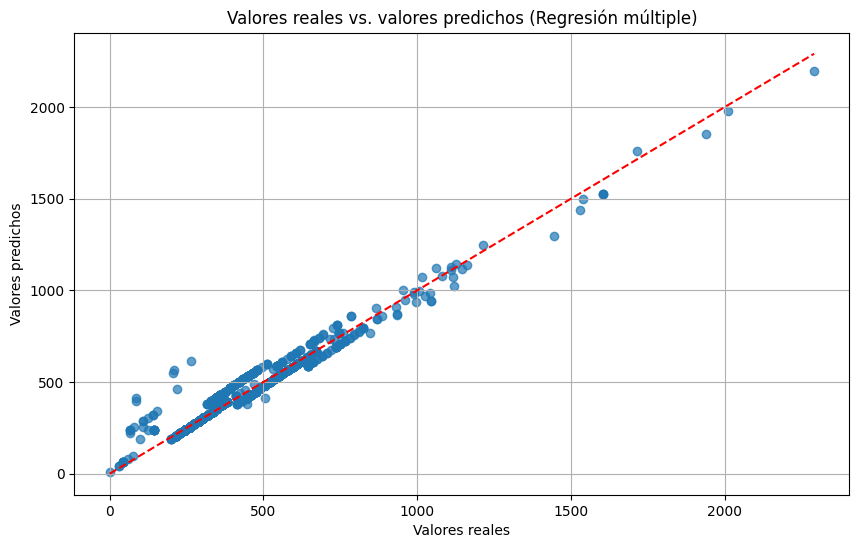

In [ ]:
# Gráfico de valores reales vs. predichos
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel('Valores reales')
plt.ylabel('Valores predichos')
plt.title('Valores reales vs. valores predichos (Regresión múltiple)')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # Línea ideal
plt.grid(True)
plt.show()

In [ ]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
#Calculo el error cuadrático medio (MSE) y el coeficiente de determinación (R^2)

In [ ]:
coeficientes = pd.DataFrame(model.coef_, X.columns, columns=['Coeficiente'])
print(coeficientes)
#Obtengo los coeficientes del modelo

NameError: name 'model' is not defined

Comentarios:

- **bathrooms**: manteniendo todas las demás variables constantes, cada baño adicional sugiere un aumento de aproximadamente 176.18 unidades en el precio.
- **bedrooms**: cada dormitorio adicional está asociado con un aumento de aproximadamente 34.16 unidades en el precio.
- **beds**: cada cama adicional está asociada con un aumento de aproximadamente 16.70 unidades en el precio.



**Quinto paso: Disponibilidad**

Muestre visualmente la disponibilidad de las ubicaciones incluidas en el listado de
Airbnb. La segunda propuesta de valor /promesa de Airbnb es brindar
un ingreso adicional para el propietario del local. Significa también que los Anfitriones
reservan su ubicación para alquiler por un período de 1 mes, máximo: 2 meses. ¿Esta
segunda promesa está alineada con lo que observas?

In [ ]:
df_filtered['availability_monthly'] = df_filtered['availability_365'] / 12
#Calculo la disponilidad media mensual teniendo la disponibilidad a 365 días

<ipython-input-48-41177139e9b5>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['availability_monthly'] = df_filtered['availability_365'] / 12


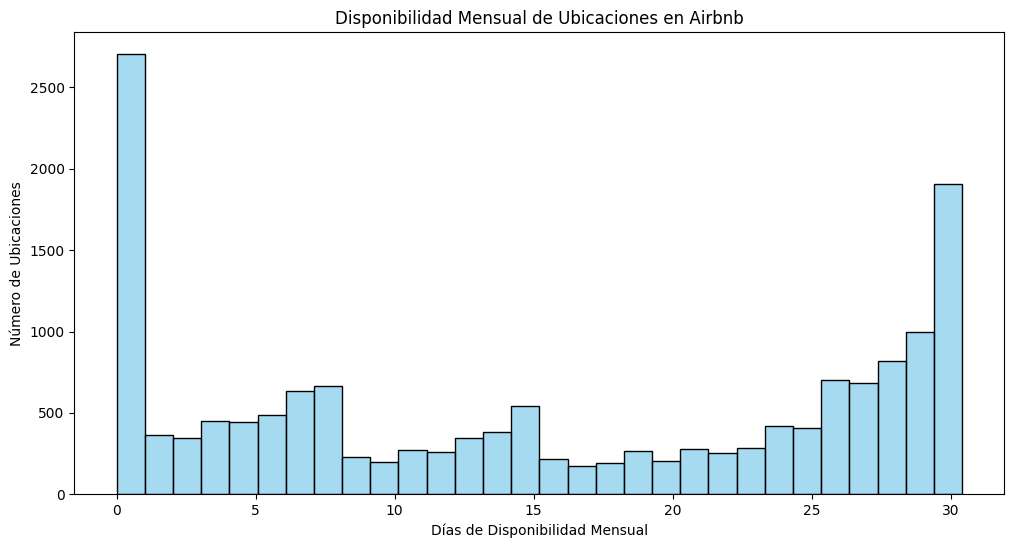

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df_filtered['availability_monthly'], bins=30, kde=False, color='skyblue')
plt.xlabel('Días de Disponibilidad Mensual')
plt.ylabel('Número de Ubicaciones')
plt.title('Disponibilidad Mensual de Ubicaciones en Airbnb')
plt.show()
#Creo un gráfico de barras para visualizar la disponibilidad mensual


In [ ]:
# Análisis
availability_monthly_mean = df_filtered['availability_monthly'].mean()

print(f'Disponibilidad media mensual: {availability_monthly_mean:.2f} días')

if 30 <= availability_monthly_mean <= 60:
    print("La disponibilidad observada está alineada con la promesa de Airbnb de reservar ubicaciones por un período de 1 a 2 meses.")
else:
    print("La disponibilidad observada no está alineada con la promesa de Airbnb de reservar ubicaciones por un período de 1 a 2 meses.")


Disponibilidad media mensual: 15.30 días
La disponibilidad observada no está alineada con la promesa de Airbnb de reservar ubicaciones por un período de 1 a 2 meses.


***Sexto paso: Visualización de sus datos: un gráfico circular***

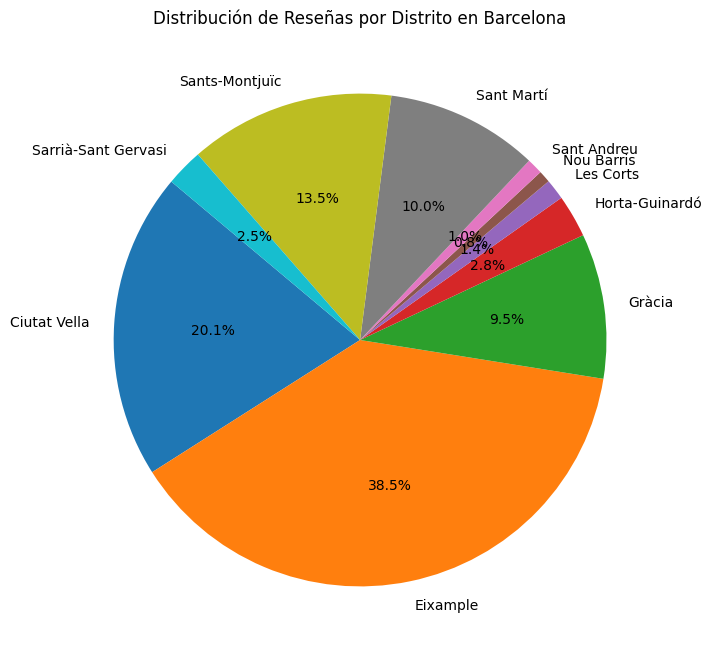

In [ ]:
reviews_by_district = df_barcelona.groupby('district')['number_of_reviews'].sum()
# Sumo las revisiones por distrito


plt.figure(figsize=(10, 8))
plt.pie(reviews_by_district, labels=reviews_by_district.index, autopct='%1.1f%%', startangle=140)
plt.title('Distribución de Reseñas por Distrito en Barcelona')
plt.show()
# Creación del gráfico circular




In [ ]:
top_2_districts = reviews_by_district.sort_values(ascending=False).head(2)
print("Los 2 distritos con más reseñas son:")
print(top_2_districts)
# Identificacion los 2 distritos con más reseñas


Los 2 distritos con más reseñas son:
district
Eixample        279863
Ciutat Vella    146408
Name: number_of_reviews, dtype: int64


In [ ]:
#Se observa que "Eixample" y "Ciutat Vella" son los distritos con la mayor cantidad de reseñas, representando el 38.5% y el 20.1% respectivamente.
 #Esto indica que estos dos distritos son las áreas más activas en Airbnb, posiblemente debido a su atractivo turístico y la mayor oferta de alojamientos. Otros distritos como "Sants-Montjuïc" y "Sant Martí" también contribuyen de manera significativa, pero en menor proporción.


# Mapeo de las ubicaciones de Airbnb en la ciudad de Barcelona.


In [ ]:
df_filtered = df_barcelona[df_barcelona['price'] < 500]
# Filtro en  el conjunto de datos para incluir solo las ubicaciones con un precio menor a 500 euros


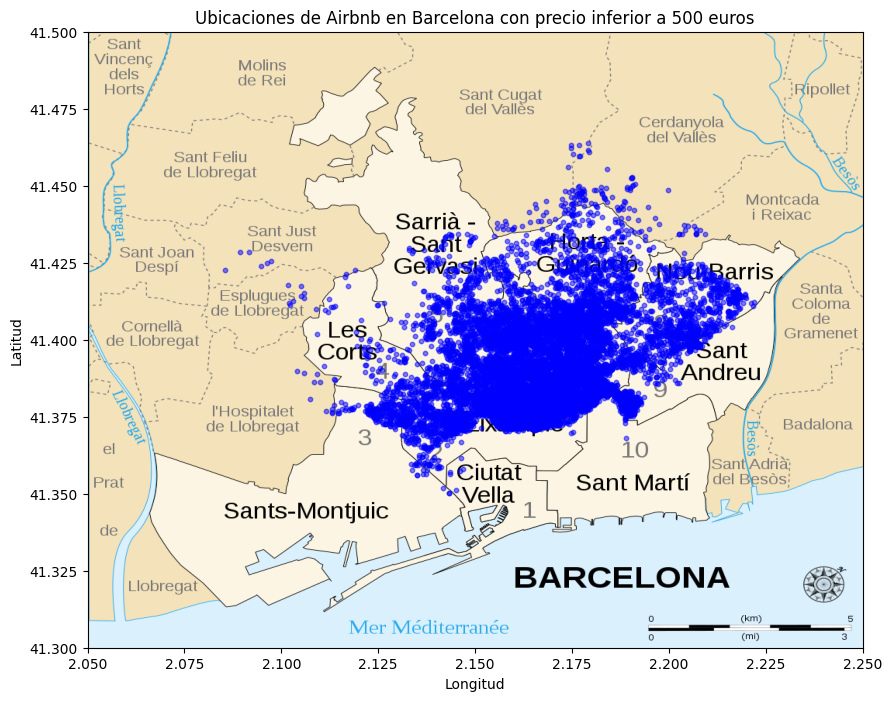

In [ ]:
img = mpimg.imread('/content/sample_data/300px-Barcelona_districtes.png')
#Se carga la imagen del mapa de Barcelona

df_filtered = df_filtered[(df_filtered['latitude'] >= 41.3) & (df_filtered['latitude'] <= 41.5) &
                          (df_filtered['longitude'] >= 2.05) & (df_filtered['longitude'] <= 2.25)]

long_min, long_max = 2.05, 2.25
lat_min, lat_max = 41.3, 41.5


#Se Definen los límites correctos para la ciudad de Barcelona


plt.figure(figsize=(10, 8))
plt.imshow(img, extent=[long_min, long_max, lat_min, lat_max], aspect='auto')

# Creación del gráfico con límites ajustados y aspecto fijo


plt.scatter(df_filtered['longitude'], df_filtered['latitude'], color='blue', alpha=0.5, s=10)

plt.title('Ubicaciones de Airbnb en Barcelona con precio inferior a 500 euros')
plt.xlabel('Longitud')
plt.ylabel('Latitud')
plt.show()

# Graficar de los puntos de Airbnb

In [ ]:
#El mapa muestra la distribución de las ubicaciones de Airbnb con precios inferiores a 500 euros en Barcelona. Aunque Airbnb promete dispersar el turismo en toda la ciudad y beneficiar a los barrios menos turísticos, se observa que la mayoría de las ubicaciones están concentradas en el centro de la ciudad y en distritos populares como "Ciutat Vella", "Eixample", y "Gràcia". Esto sugiere que el turismo se sigue concentrando principalmente en áreas centrales y turísticas, en lugar de estar distribuido equitativamente por toda la ciudad.
#Esto podría implicar que la propuesta de valor de Airbnb de diversificar el turismo por todos los barrios de la ciudad no se está cumpliendo completamente, ya que los barrios menos turísticos siguen teniendo una baja densidad de alojamientos. Sin embargo, la concentración en áreas específicas puede deberse a que estas zonas tienen mayor demanda turística o mejores infraestructuras para alojamientos temporales.
#En conclusión, la dispersión del turismo en Barcelona no parece estar distribuida de manera uniforme, lo cual podría limitar el impacto de la propuesta de valor de Airbnb de beneficiar a todos los barrios por igual.


In [ ]:
#Conclusiones
#Con base a las tres propuestas de valor de Airbnb, se puede observar que de acuerdo con cada una de las características que se pretenden abarcar, el estudio encontró:
#1.	Difusión del Turismo: No se valida completamente, ya que los alojamientos están concentrados en áreas céntricas y turísticas, lo que implica que Airbnb no está logrando difundir el turismo en toda la ciudad.
#2.	Ingresos Adicionales para Anfitriones: Existe cierta validación, pues hay anfitriones que mantienen sus propiedades disponibles durante todo el mes. Esto sugiere que algunos anfitriones están generando ingresos adicionales. Sin embargo, para una validación más sólida, se requeriría información más detallada sobre los ingresos.
#3.	Mejora de la Experiencia Turística: Parece estar validada en zonas turísticas clave, dado el alto número de reseñas en estos distritos. Sin embargo, la experiencia parece estar limitada a las zonas populares, lo que podría indicar que los huéspedes no están explorando áreas menos turísticas de la ciudad.
#De lo anterior, aunque hay indicios de que algunas de las propuestas de valor de Airbnb se cumplen parcialmente, especialmente en las áreas centrales de Barcelona, la idea de dispersar el turismo y ofrecer experiencias únicas en barrios menos turísticos no se está logrando del todo.
#Se sugiere a Airbnb implementar estrategias para promover alojamientos en barrios menos conocidos, ofreciendo incentivos a los anfitriones en esas áreas y destacando experiencias locales únicas. Además, sería útil mejorar la promoción de estos barrios entre los huéspedes, con el objetivo de diversificar el turismo en la ciudad y validar plenamente la propuesta de valor de difundir el turismo en toda la ciudad.



